In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from math import comb

In [ ]:
with open("net.tntp", "r") as file:
    for line in file:
        if line.strip().startswith("~"):
            header = line.strip().split()
            break
    df = pd.read_csv(file, sep='\s+', names=header)

df = df.rename(columns={
    '~':'Start_node',
    'init_node': 'End_node',
    'term_node': 'Capacity',
    'capacity': 'length',
    'length': 'Free_flow_time',
    'free_flow_time': 'B',
    'b': 'Power',
    'power': 'Speed',
    'speed': 'Toll',
    'toll': 'Link_type'
})

df = df.drop('link_type', axis=1)
df = df.drop(';', axis=1)
df.head()

,Start_node,End_node,Capacity,length,Free_flow_time,B,Power,Speed,Toll,Link_type
0,1,547,49500,0.86267,0.0,0.15,4,0,0,3
1,2,548,49500,0.86267,0.0,0.15,4,0,0,3
2,3,549,49500,0.86267,0.0,0.15,4,0,0,3
3,4,550,49500,0.86267,0.0,0.15,4,0,0,3
4,5,551,49500,0.86267,0.0,0.15,4,0,0,3


The other files are not relevant to my EDA:
- "flow" dataset is the best known flow solution
- "trips": this is the "origin destination demand data", which shows the volume of people traveling from one zone to another
- "node": this is simply a dictionary correlating each node to its coordinates

The first step I'll take is making an Adjacency matrix.


In [ ]:
A = np.zeros((933,933))

for _, row in df.iterrows():
  s = int(row['Start_node'])
  t = int(row['End_node'])
  A[t-1, s-1] += 1 # A[i][j] = 1 if there is a path from j to i

print(A)
print("\n")
print("Number of edges:", np.sum(A))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Number of edges: 2950.0


This is the correct number of links - the data says that there are 2950 links total.

Next I will look at how many paths of length 2 there are, how many paths of length 3, etc...

In [ ]:
# number of self-edges:
print("Number of self-edges: ", int(A.trace()))
print("Number of loops of length 2: ", int((np.linalg.matrix_power(A, 2)).trace()))


# for n in range(1,31):
#   A_to_n = np.linalg.matrix_power(A, n)
#   if int(A_to_n.trace()) != 0:
#     print(f"Number of loops of length {n}: {int(A_to_n.trace())}")

Number of self-edges:  0
Number of loops of length 2:  2950


That's weird. Why are there exactly 2950 loops of length 2, when the total number of edges is also 2950? Actually no, it makes sense. I guess it's because for every two nodes i and j, if there is a link, then there is one from i to j, and one from j to i. In other words, for every single multi-directional "edge", it is actually a path of length 2. So then the number of loops of length 2 = the number of edges. Okay, yeah.

In that case, the number of strongly-connected components should be 1. Let's test it out.

In [ ]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)
print(f"Number of strongly connected components: {nx.number_strongly_connected_components(G)}")
print(f"\nNumber of weakly connected components: {nx.number_weakly_connected_components(G)}")

Number of strongly connected components: 1

Number of weakly connected components: 1


Exactly as expected! Great.

In fact, I wonder. Though the network is directed, could its adjacency matrix be symmetric? Let's check it out. I'm taking this function from https://stackoverflow.com/questions/42908334/checking-if-a-matrix-is-symmetric-in-numpy

In [ ]:
def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)

print(f"Is the adjacency matrix symmetric? {check_symmetric(A)}")

Is the adjacency matrix symmetric? True


It is! So we can honestly treat this network as an undirected network in the exploratory analysis. Every edge simply represents a "road", which means that each time we have a road, we can go in both directions.

From now on, we will treat the network as **undirected**.

Great. Now, let's move onto **density, mean degree, etc**.

In [ ]:
# graph is now undirected
G = nx.from_numpy_array(A)

# number of edges = sum of degrees / 2
# connectance = number of edges / number of possible edges

p = (A.sum()/2) / comb(933, 2)
print(f"Connectance: {p}")

Connectance: 0.0033925359608811853


^ This connectance considers edges coming in both directions from each node.

Now, since we have a directed network, we can get the mean degree.  




In [ ]:
# c = (n-1)*p
print(f"Mean degree from connectance: {932*p}")
print(f"Mean degree from adjacency matrix: {np.mean(np.sum(A, axis=0))}")

Mean degree from connectance: 3.1618435155412645
Mean degree from adjacency matrix: 3.1618435155412645


So, on average, for each node, there are 3 roads that you can use to get into or out of it. Note that this is the **average**. In reality, in downtown, this is probably very high, and on the outskirts of the town, this number is very low. However, we will get into different centrality measures later in the project.

Finally let's move onto **capturing groups**.

In [ ]:
for num in range(1,10):
  my_str = str(nx.k_core(G, k=num))
  print(f"Size of {num}-core: {my_str[10:]}")

Size of 1-core:  933 nodes and 1475 edges
Size of 2-core:  529 nodes and 1071 edges
Size of 3-core:  475 nodes and 966 edges
Size of 4-core:  0 nodes and 0 edges
Size of 5-core:  0 nodes and 0 edges
Size of 6-core:  0 nodes and 0 edges
Size of 7-core:  0 nodes and 0 edges
Size of 8-core:  0 nodes and 0 edges
Size of 9-core:  0 nodes and 0 edges


So it looks like the largest k-core is of size 3. That means that in this network, there is some set where each node is connected to at least 3 others in the set. However, once we get to 4 and up, there is no k-core.

K-components are taking a long long time so I'll do that later.

In [ ]:
print(nx.k_components(G))

Finally, let's finish up with some visualizations.

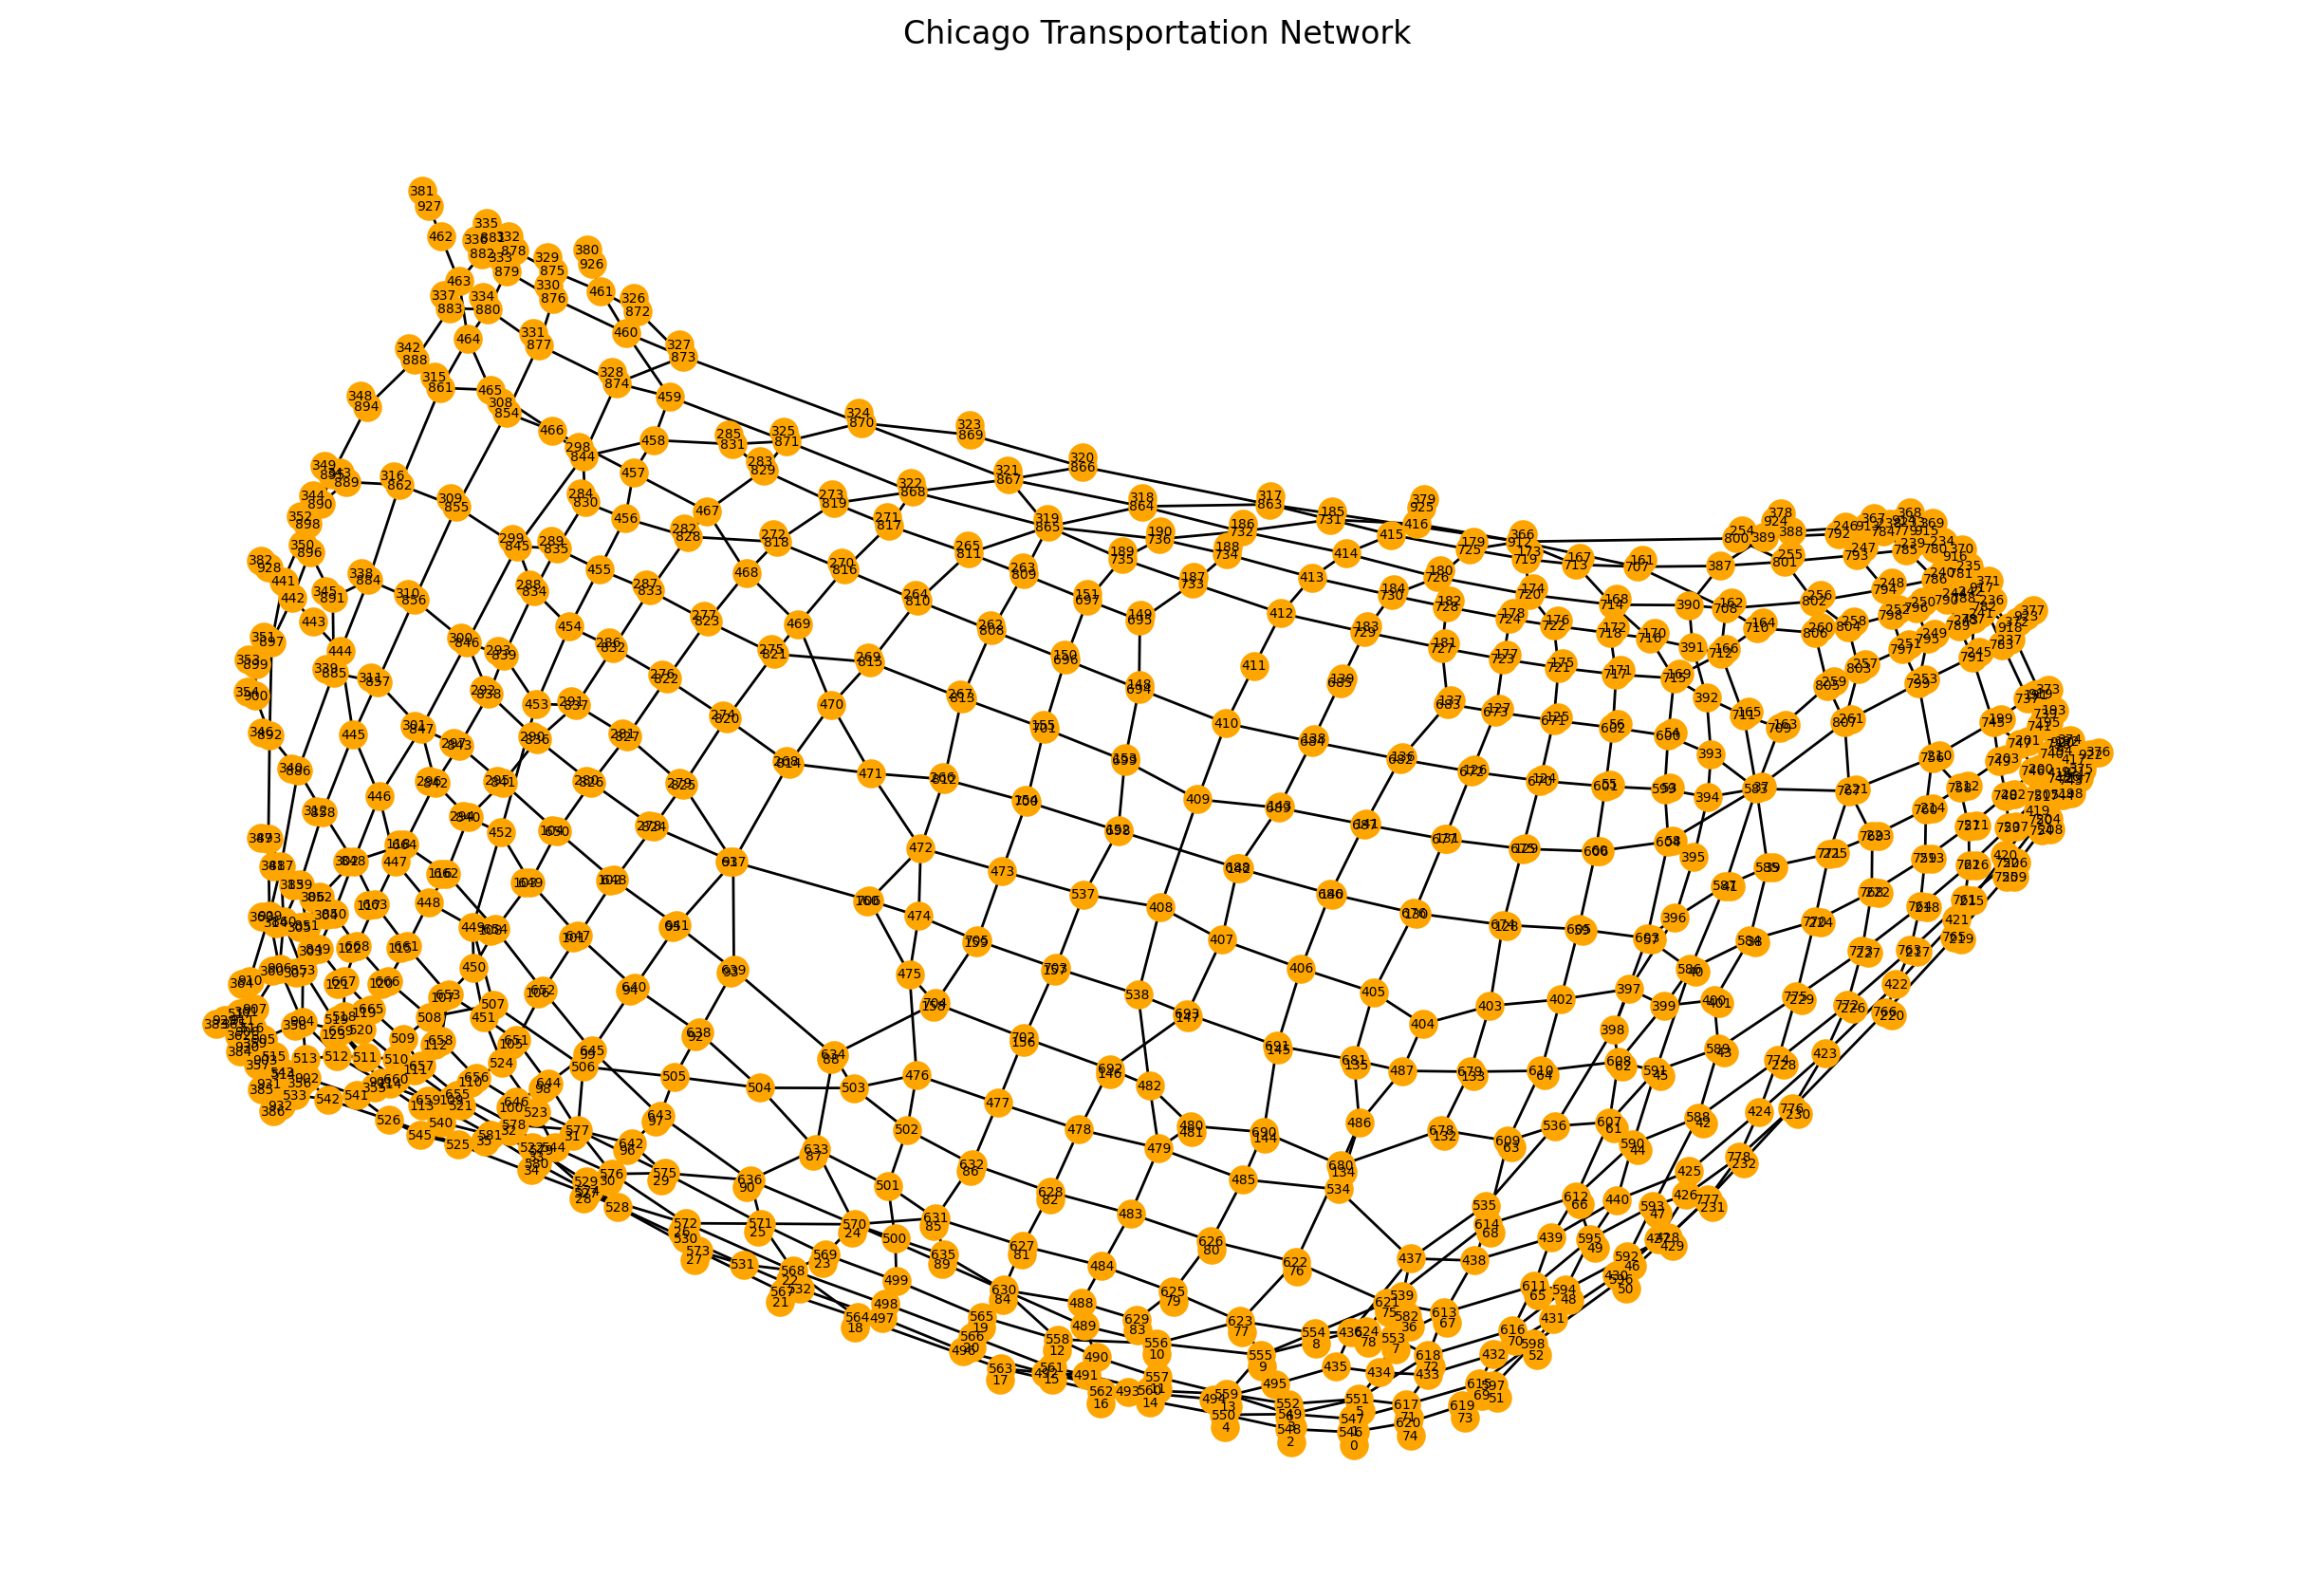

In [ ]:
import matplotlib.pyplot as plt

pos = nx.spectral_layout(G)
plt.figure(figsize=(12, 8), dpi=200)
nx.draw(G,
        pos,
        with_labels=True,
        node_color='orange',
        node_size=100,
        font_size=5)
plt.title("Chicago Transportation Network")
plt.show()

NOTE: DO NOT INCLUDE THIS VISUALIZATION IN THE REPORT BC THE NUMBERS ARE TOO SMALL!!!! This is just for the group

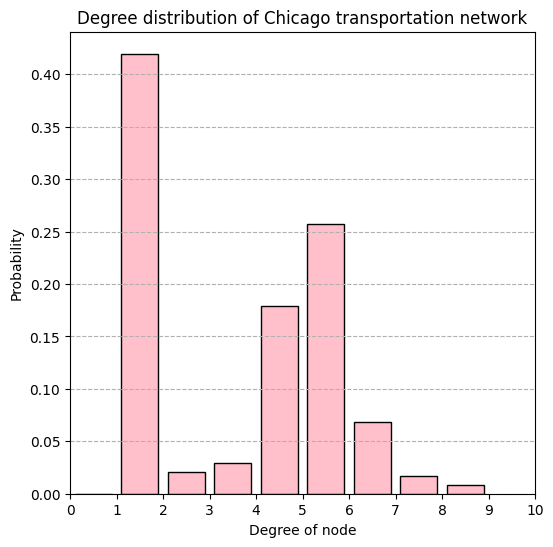

In [ ]:
degrees = [G.degree(n) for n in G.nodes()]
plt.figure(figsize=(6,6),dpi=100)
plt.hist(degrees,
         bins = range(0, 10, 1),
         density=True,
         color="pink",
         edgecolor="black",
         rwidth=0.8)

plt.xlabel("Degree of node")
plt.ylabel("Probability")
plt.title("Degree distribution of Chicago transportation network")

plt.xlim(0, 10)
plt.xticks(range(0, 11, 1))
plt.grid(axis="y", linestyle="--")

plt.show()

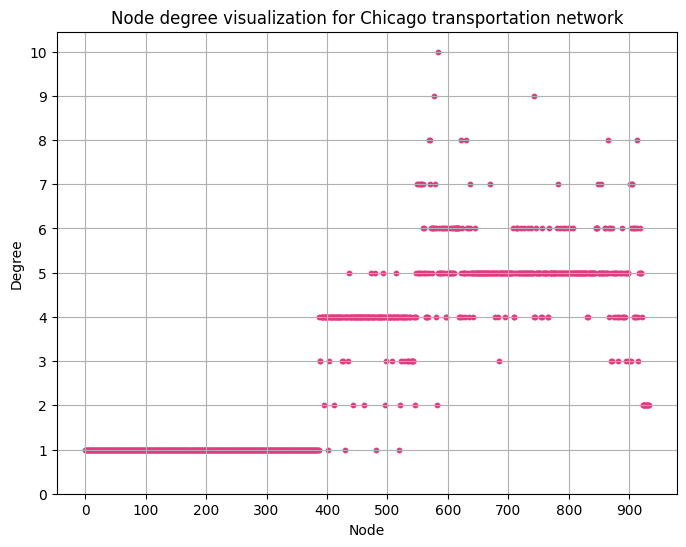

In [ ]:
# degree visualization for all 900 nodes
import matplotlib.pyplot as plt
node_degrees = [G.degree(n) for n in G.nodes()]
nodes = list(G.nodes())

plt.figure(figsize=(8,6), dpi=100)
plt.scatter(nodes,
            node_degrees,
            color='#e63780',
            s=10)

plt.xticks(range(0, 1000, 100))
plt.yticks(range(0, 11, 1))
plt.xlabel("Node")
plt.ylabel("Degree")
plt.title("Node degree visualization for Chicago transportation network")
plt.grid(True)

plt.show()


^ it would be interesting to have the x-axis be how far away this datapoint is from downtown...

**ask shilpa how she got the real coordinates from illinois state plane**


# Next steps:

- figure out how to get the k-components (try VSCode, it might be faster than Colab)  
      - Shilpa's work is in the map_overlay file in her github
- plot "Node's distance from downtown" vs "degree" (I predict a negative correlation)
- plot flow of node vs degree?? (here I predict a positive correlation)
- make overleaf doc and ask Sarah to share  